In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Library untuk cek ditribusi
from scipy.stats import norm
# Library untuk uji hipotesis
from scipy.stats import kruskal
from scipy.stats import spearmanr
# library untuk model prediksi
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


In [366]:
df = pd.read_csv("C:\Dibimbing\\time series\dataset\\train.csv")
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [368]:
df.duplicated().sum()

np.int64(0)

In [369]:
df.shape

(3000888, 6)

- kolom: 6
- baris: 3.000.888

In [370]:
# angar data angka tidak menggunakan angka scientific
pd.options.display.float_format = '{:.2f}'.format

In [371]:
# statistik data numerik
df.describe()

,id,store_nbr,sales,onpromotion
count,3000888.00,3000888.00,3000888.00,3000888.00
mean,1500443.50,27.50,357.78,2.60
std,866281.89,15.59,1102.00,12.22
min,0.00,1.00,0.00,0.00
25%,750221.75,14.00,0.00,0.00
50%,1500443.50,27.50,11.00,0.00
75%,2250665.25,41.00,195.85,0.00
max,3000887.00,54.00,124717.00,741.00


In [372]:
df['onpromotion'].sum()

np.int64(7810622)

In [373]:
df[['sales', 'onpromotion']].describe()

,sales,onpromotion
count,3000888.00,3000888.00
mean,357.78,2.60
std,1102.00,12.22
min,0.00,0.00
25%,0.00,0.00
50%,11.00,0.00
75%,195.85,0.00
max,124717.00,741.00


- sales: memiliki varian yang banyak dan indikasi right skewed (mean > median)

In [374]:
# statistik data object
df['family'].describe()

count        3000888
unique            33
top       AUTOMOTIVE
freq           90936
Name: family, dtype: object

- banyak produk automotive

In [375]:
dfc = df.copy()

In [376]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [377]:
# membuat tampilan dataframe menjadi full (tidak terpotong)
pd.set_option('display.max_colwidth', None)

In [378]:
# Pemeriksaan unique value
obj_col = dfc.select_dtypes(include=["object"]).columns
obj_value = []

for col in obj_col:
    obj_value.append({
        "column_name": col,
        "n_unique": dfc[col].nunique(dropna=True),
        "n_missing": dfc[col].isna().sum(),
        "top_5_value": dfc[col].value_counts().head(5).to_dict()
    })

dfc_obj_value = pd.DataFrame(obj_value)

dfc_obj_value

,column_name,n_unique,n_missing,top_5_value
0,date,1684,0,"{'2017-08-15': 1782, '2013-01-01': 1782, '2013-01-02': 1782, '2013-01-03': 1782, '2017-07-30': 1782}"
1,family,33,0,"{'AUTOMOTIVE': 90936, 'BABY CARE': 90936, 'BEAUTY': 90936, 'BEVERAGES': 90936, 'BOOKS': 90936}"


In [379]:
# data unique pada kolom family
df['family'].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [380]:
# Pemeriksaan missing value
dfc_na = pd.DataFrame({
	'missing_value' : dfc.isna().sum(),
	'percentage(%)' : round((dfc.isna().mean()*100), 2),
	'data_type' : dfc.dtypes
})

total_cells = dfc.shape[0] * dfc.shape[1]
total_missing = dfc_na["missing_value"].sum()
percentage_total = (total_missing / total_cells) * 100

print(dfc_na[dfc_na['missing_value'] > 0].sort_values(by="missing_value", ascending=False))
print("\n")
print("Jumlah missing value: ", total_missing)
print("Persentase missing value (%): ", round(percentage_total, 2))

Empty DataFrame
Columns: [missing_value, percentage(%), data_type]
Index: []


Jumlah missing value:  0
Persentase missing value (%):  0.0


In [381]:
# ubah tipe data date menjadi datetime
dfc['date'] = pd.to_datetime(dfc['date'])
dfc.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

In [382]:
col_numeric = dfc[['sales']]
col_numeric.head()

,sales
0,0.00
1,0.00
2,0.00
3,0.00
4,0.00


In [383]:
# Membuat tabel pemeriksaan outlier
# Metode pemriksaan outlier: IQR
outlier_summary = {}

for n in col_numeric:
    Q1 = dfc[n].quantile(0.25) # Mendapatkan nilai 25% dari dataset
    Q3 = dfc[n].quantile(0.75) # Mendapatkan nilai 75% dari dataset
    IQR = Q3 - Q1

    lowerbond = Q1 - 1.5*IQR # Medapatkan nilai batas bawah outlier
    upperbond = Q3 + 1.5*IQR # Medapatkan nilai batas atas outlier

    outlier = dfc[(dfc[n] < lowerbond) | (dfc[n] > upperbond)] # outlier adalah nilai diatas nilai uppperbond atau dibawah lowerbond

    # Variable untuk merangkum perhitungan metode IQR dalam bentuk dictionary
    outlier_summary[n] = {
        "lower_bond" : lowerbond,
        "upper_bond" : upperbond,
        "n_outlier" : len(outlier), # jumlah data yang termasuk outlier
        "percentage" : len(outlier)/len(dfc[n])*100 # persentase
    }

In [384]:
pd.DataFrame(outlier_summary)

,sales
lower_bond,-293.77
upper_bond,489.62
n_outlier,447105.00
percentage,14.90


- outlier dibiarkan untuk kebutuhan analisa dan insight bisnis

In [385]:
# status sales: jika 1, terdapat nilai sales (terdapat penjualan), jika 0 tidak terdapat nilai sales (tidak ada penjualan)
dfc['sales_status'] = (df['sales'].fillna(0) > 0).astype(int)

In [386]:
dfc.tail(1)

,id,date,store_nbr,family,sales,onpromotion,sales_status
3000887,3000887,2017-08-15,9,SEAFOOD,16.00,0,1


In [387]:
dfc.head(1)

,id,date,store_nbr,family,sales,onpromotion,sales_status
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,0


In [388]:
# Setting warna visualisasi global
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
# Mengubah warna default komponen boxplot secara global menjadi putih
plt.rcParams["boxplot.boxprops.color"] = "white"
plt.rcParams["boxplot.whiskerprops.color"] = "white"
plt.rcParams["boxplot.capprops.color"] = "white"
plt.rcParams["boxplot.medianprops.color"] = "orange"  # Oranye untuk median

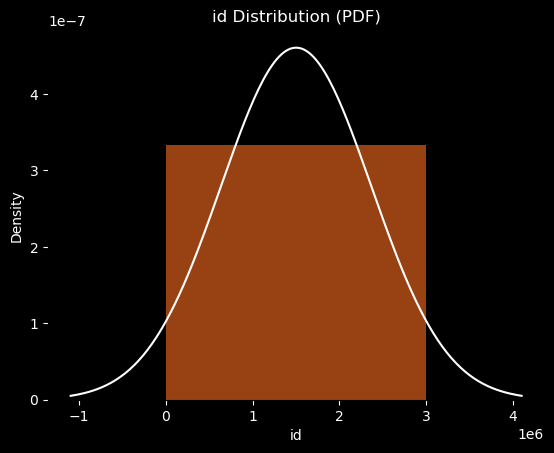

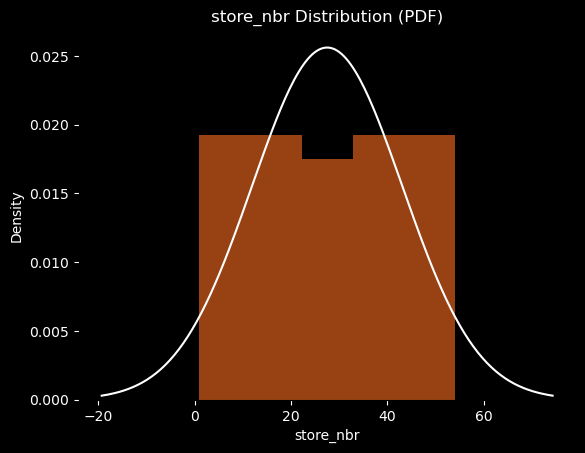

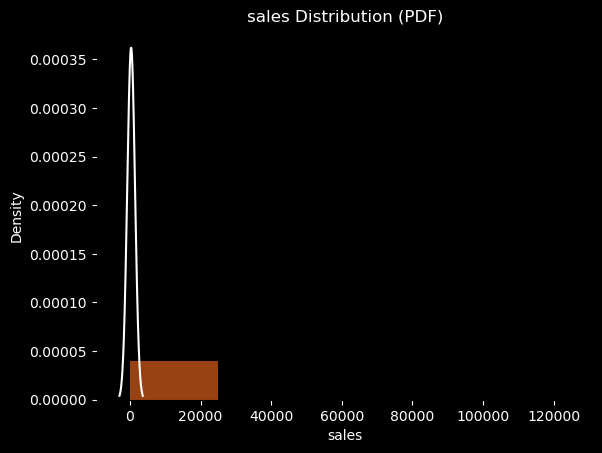

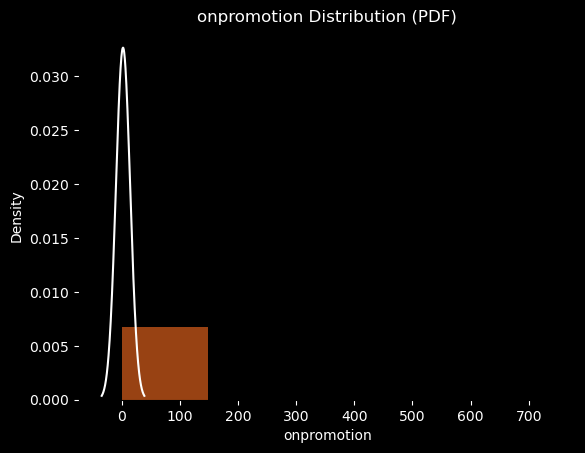

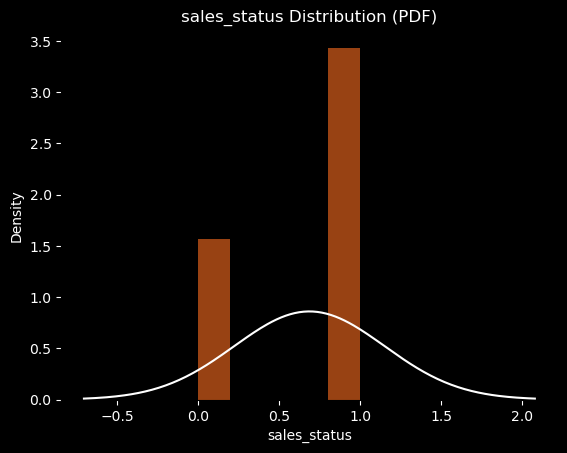

In [389]:
# Memabuat histrogram untuk melaukan pemeriksaan distribusi kerapatan data
dfc_col_num = dfc.select_dtypes(include='number')
# Membuat garis normalitas
for col in dfc_col_num:
    mu = dfc[col].mean()
    sigma = np.std(dfc[col])
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 200) 
    pdf = norm.pdf(x, mu, sigma)

    # Membuat histogram distribusi untuk setiap kolom numerik
    plt.hist(
        dfc[col], 
        bins = 5, 
        density=True, 
        alpha=0.6,
        color= "#FF6F20"
        )
    plt.plot(
        x, 
        pdf, 
        color='white'
        )
    
    plt.title(f"{col} Distribution (PDF)")
    plt.xlabel(f"{col}")
    plt.ylabel("Density")
    plt.show()

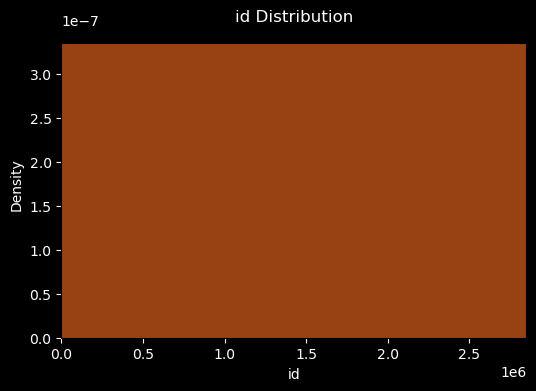

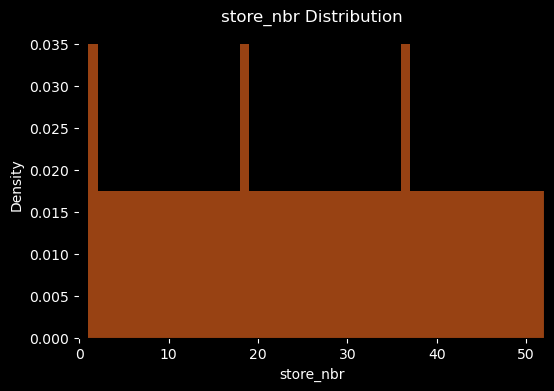

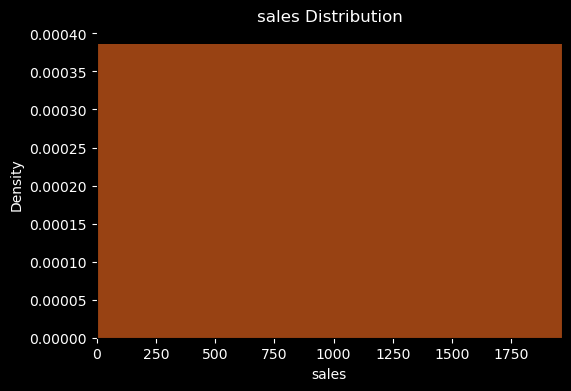

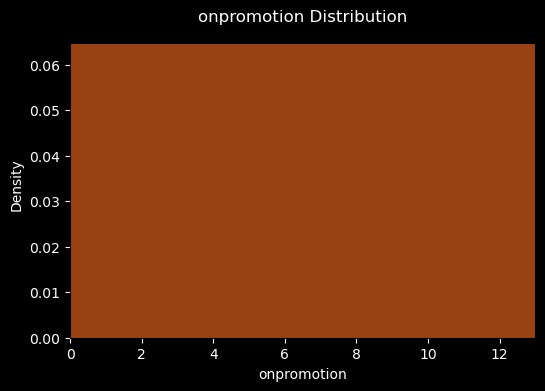

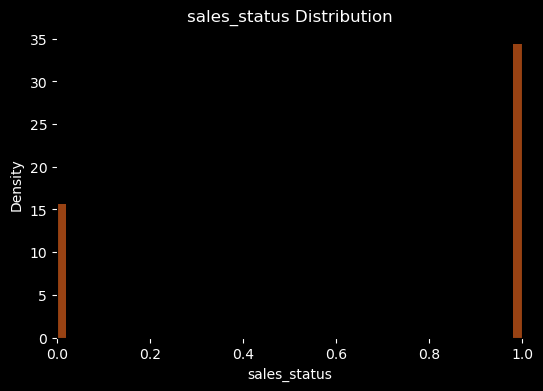

In [390]:
for col in dfc.select_dtypes(include='number').columns:
    data = dfc[col].dropna()
    
    plt.figure(figsize=(6,4))
    
    plt.hist(data, bins=50, density=True, alpha=0.6, color="#FF6F20")
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Density")
    
    plt.xlim(0, data.quantile(0.95))  # penting
    
    plt.show()

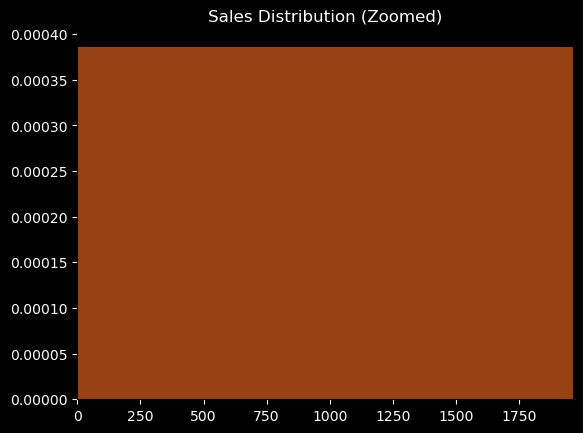

In [391]:
plt.hist(dfc['sales'], bins=50, density=True, alpha=0.6, color="#FF6F20")
plt.xlim(0, dfc['sales'].quantile(0.95))  # zoom 95%
plt.title("Sales Distribution (Zoomed)")
plt.show()

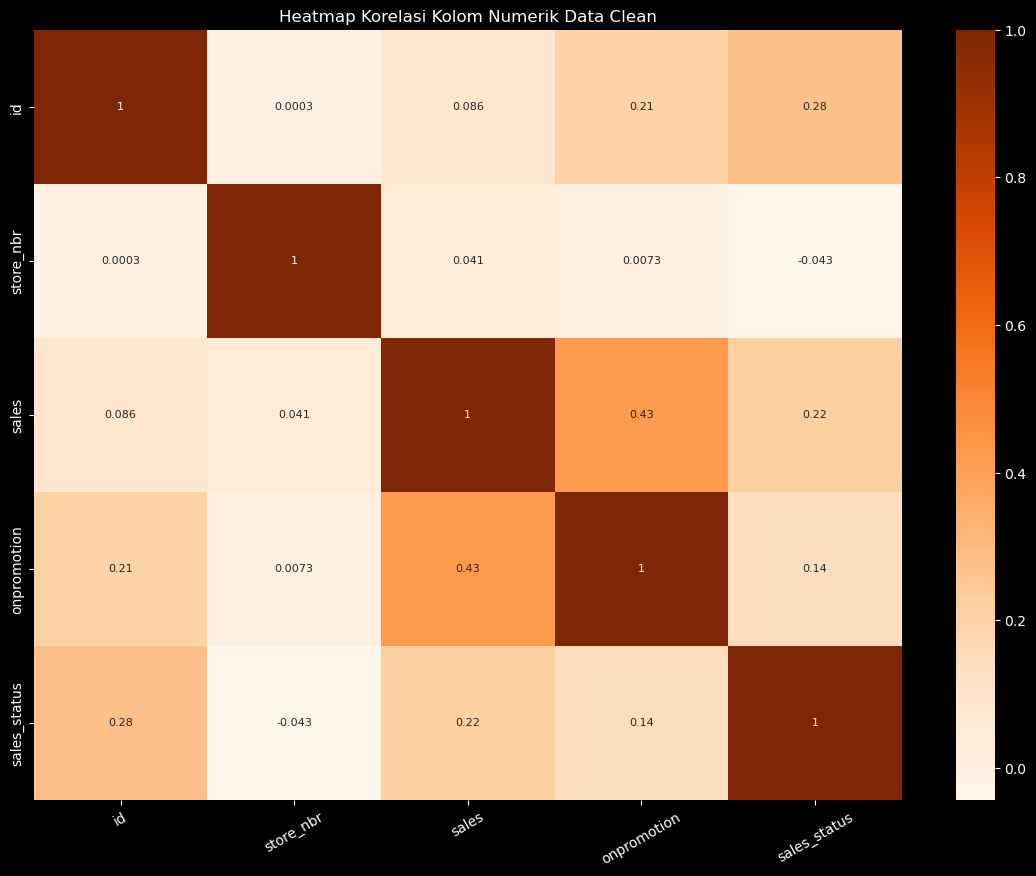

In [392]:
# Membuat dataframe kolom numerik
dfc_num = dfc.select_dtypes(include='number')

# Membuat heatmap korelasi kolom numerik
corr = dfc_num.corr()

plt.figure(figsize=(14,10))  # atur sesuai kebutuhan
# Heatmap untuk kolom numerik dataframe dfc
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={'size':8}, 
    cmap='Oranges'
    )

plt.title('Heatmap Korelasi Kolom Numerik Data Clean')
plt.xticks(rotation = 30)
plt.show()

In [393]:
# Uji korelasi/hubungan kolom Discount vs profit_margin
corr, p_value = spearmanr(dfc['sales'], df['onpromotion'])

print(f"Nilai corr/rho: {corr}")
print(f"Nilai P-Value: {p_value}")
print('\n')

if p_value < 0.05:
    print(f"P-Value: {p_value} < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan")

else:
    print(f"P-Value: {p_value} >= 0.05, maka gagal Tolak H0: kemungkinan tidak memiliki hubungan")

Nilai corr/rho: 0.5380218163559218
Nilai P-Value: 0.0


P-Value: 0.0 < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan


In [394]:
dfc.groupby('family')[['sales', 'sales_status']].mean().sort_values('sales', ascending=False)

,sales,sales_status
family,,
GROCERY I,3776.97,0.92
BEVERAGES,2385.79,0.92
PRODUCE,1349.35,0.72
CLEANING,1072.42,0.92
DAIRY,709.15,0.92
BREAD/BAKERY,463.34,0.92
POULTRY,350.53,0.92
MEATS,341.85,0.92
PERSONAL CARE,270.43,0.92


In [395]:
# target encoding dengan memberi nilai tiap kategori family dengan mencari rata-rata tiap kategori
dfc['family_te'] = df.groupby('family')['sales'].transform('mean')

In [396]:
corr = dfc[['sales', 'sales_status', 'store_nbr', 'onpromotion', 'family_te']].corr()

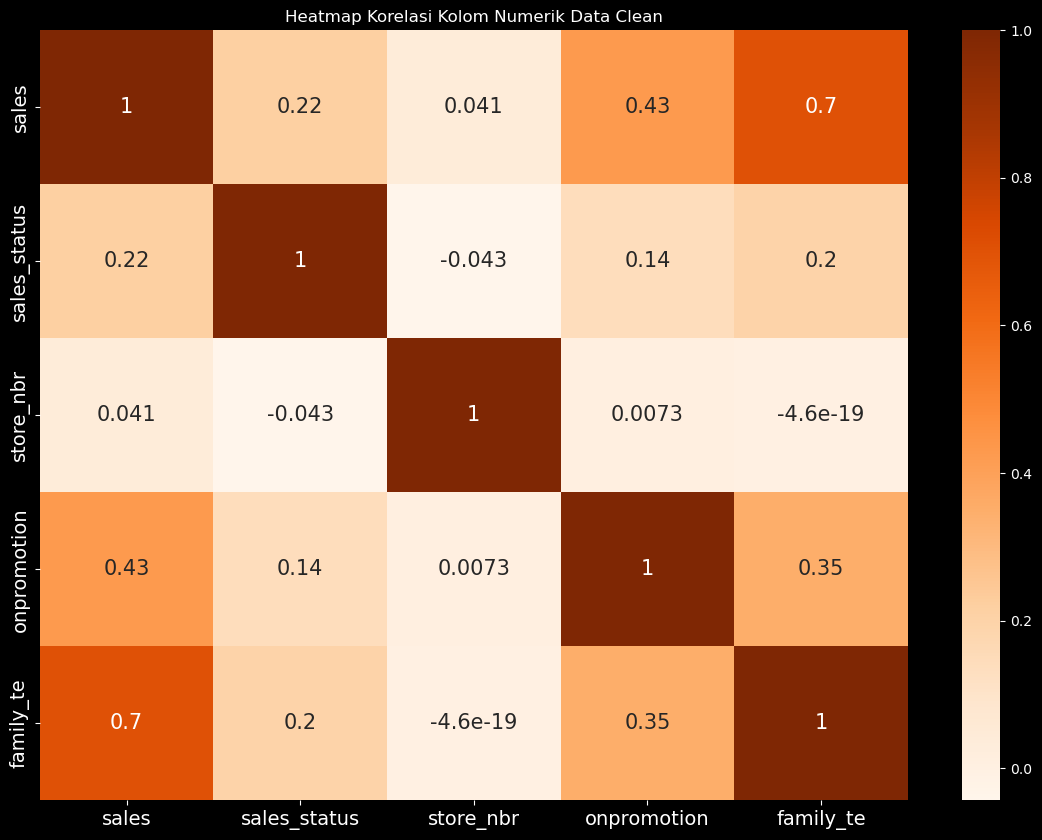

In [397]:
plt.figure(figsize=(14,10))  # atur sesuai kebutuhan
# Heatmap untuk kolom numerik dataframe dfc
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={'size':15}, 
    cmap='Oranges'
    )

plt.title('Heatmap Korelasi Kolom Numerik Data Clean')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [398]:
# grouping data berdasarkan family
groups_family = [
    group['sales'].values 
    for name, group in df.groupby('family')
]

# uji kruskal
stat_family, p_family = kruskal(*groups_family)

print("Kruskal-Wallis Test (sales vs family)")
print("Statistic:", stat_family)
print("P-value:", p_family)

Kruskal-Wallis Test (sales vs family)
Statistic: 1800262.2960342665
P-value: 0.0


In [399]:
# grouping data berdasarkan store
groups_store = [
    group['sales'].values 
    for name, group in df.groupby('store_nbr')
]

# uji kruskal
stat_store, p_store = kruskal(*groups_store)

print("\nKruskal-Wallis Test (sales vs store_nbr)")
print("Statistic:", stat_store)
print("P-value:", p_store)


Kruskal-Wallis Test (sales vs store_nbr)
Statistic: 266880.4611403738
P-value: 0.0


In [400]:
alpha = 0.05

if p_family < alpha:
    print("Ada perbedaan signifikan sales antar family")
else:
    print("Tidak ada perbedaan signifikan sales antar family")

if p_store < alpha:
    print("Ada perbedaan signifikan sales antar store")
else:
    print("Tidak ada perbedaan signifikan sales antar store")

Ada perbedaan signifikan sales antar family
Ada perbedaan signifikan sales antar store


In [401]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 8 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   sales_status  int64         
 7   family_te     float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 183.2+ MB


In [402]:
dfclean = dfc[['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'sales_status']]

In [403]:
dfclean.head()

,id,date,store_nbr,family,sales,onpromotion,sales_status
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,0
1,1,2013-01-01,1,BABY CARE,0.00,0,0
2,2,2013-01-01,1,BEAUTY,0.00,0,0
3,3,2013-01-01,1,BEVERAGES,0.00,0,0
4,4,2013-01-01,1,BOOKS,0.00,0,0


In [404]:
# download dataframe menjadi csv
#dfclean.to_csv('timeseriesclean.csv', index=False)

In [405]:
dfc.tail()

,id,date,store_nbr,family,sales,onpromotion,sales_status,family_te
3000883,3000883,2017-08-15,9,POULTRY,438.13,0,1,350.53
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.55,1,1,96.77
3000885,3000885,2017-08-15,9,PRODUCE,2419.73,148,1,1349.35
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.00,8,1,2.96
3000887,3000887,2017-08-15,9,SEAFOOD,16.00,0,1,22.16


In [406]:
# deskripsi statistik sales setiap family
dfc.groupby('family')['sales'].describe()

,count,mean,std,min,25%,50%,75%,max
family,,,,,,,,
AUTOMOTIVE,90936.00,6.10,6.19,0.00,2.00,5.00,8.00,255.00
BABY CARE,90936.00,0.11,0.68,0.00,0.00,0.00,0.00,116.00
BEAUTY,90936.00,3.72,4.79,0.00,0.00,2.00,5.00,136.00
BEVERAGES,90936.00,2385.79,2307.88,0.00,897.00,1784.00,3119.00,25413.00
BOOKS,90936.00,0.07,0.55,0.00,0.00,0.00,0.00,51.00
BREAD/BAKERY,90936.00,463.34,368.25,0.00,184.00,401.00,645.00,4551.30
CELEBRATION,90936.00,8.37,15.93,0.00,0.00,3.00,12.00,1783.00
CLEANING,90936.00,1072.42,734.68,0.00,630.00,938.00,1378.00,11377.00
DAIRY,90936.00,709.15,671.95,0.00,259.00,520.00,926.00,5636.00


In [407]:
# deskripsi statistik sales setiap store
dfc.groupby('store_nbr')['sales'].describe()

,count,mean,std,min,25%,50%,75%,max
store_nbr,,,,,,,,
1,55572.00,254.53,596.83,0.00,1.00,19.00,166.00,9065.00
2,55572.00,387.92,1079.56,0.00,2.00,23.22,291.00,124717.00
3,55572.00,908.41,2146.19,0.00,4.00,64.00,586.00,21858.00
4,55572.00,340.27,801.13,0.00,1.00,19.00,257.13,8969.00
5,55572.00,280.58,652.59,0.00,1.00,19.00,237.00,8216.62
6,55572.00,453.17,1072.35,0.00,1.00,29.00,356.72,12878.00
7,55572.00,484.99,1139.71,0.00,2.00,27.24,300.73,12907.00
8,55572.00,548.73,1275.42,0.00,3.00,39.00,372.24,13511.00
9,55572.00,475.23,1269.62,0.00,1.00,18.00,396.00,38422.62


In [408]:
store_agg = dfc.groupby('store_nbr').agg(
    total_sales=('sales', 'sum'),
    avg_sales=('sales', 'mean'),
    sales_success_rate=('sales_status', 'mean')  # ini otomatis jadi persentase
).reset_index().sort_values(by='total_sales', ascending=False).head(10)
store_agg

,store_nbr,total_sales,avg_sales,sales_success_rate
43,44,62087553.25,1117.25,0.82
44,45,54498010.42,980.67,0.81
46,47,50948310.06,916.80,0.81
2,3,50481910.19,908.41,0.82
48,49,43420095.78,781.33,0.81
45,46,41896062.12,753.91,0.81
47,48,35933130.27,646.60,0.79
50,51,32911489.54,592.23,0.80
7,8,30494286.93,548.73,0.80
49,50,28653020.62,515.60,0.79


In [409]:
dfc['sales_status'].mean()

np.float64(0.6870493000738448)

In [410]:
family_agg = dfc.groupby('family').agg(
    total_sales=('sales', 'sum'),
    avg_sales=('sales', 'mean'),
    sales_success_rate=('sales_status', 'mean')  # ini otomatis jadi persentase
).reset_index().sort_values(by='total_sales', ascending=False).head(10)
family_agg

,family,total_sales,avg_sales,sales_success_rate
12,GROCERY I,343462734.89,3776.97,0.92
3,BEVERAGES,216954486.00,2385.79,0.92
30,PRODUCE,122704684.68,1349.35,0.72
7,CLEANING,97521289.00,1072.42,0.92
8,DAIRY,64487709.00,709.15,0.92
5,BREAD/BAKERY,42133945.58,463.34,0.92
28,POULTRY,31876004.47,350.53,0.92
24,MEATS,31086468.40,341.85,0.92
25,PERSONAL CARE,24592051.00,270.43,0.92
9,DELI,24110322.47,265.14,0.92


In [411]:
dfc.groupby('store_nbr', as_index=False)['sales'].mean().sort_values(by='sales', ascending=False).head(10)

,store_nbr,sales
43,44,1117.25
44,45,980.67
46,47,916.80
2,3,908.41
48,49,781.33
45,46,753.91
47,48,646.60
50,51,592.23
7,8,548.73
49,50,515.60


In [412]:
dfc.groupby('family', as_index=False)['sales'].mean().sort_values(by='sales', ascending=False).head(10)

,family,sales
12,GROCERY I,3776.97
3,BEVERAGES,2385.79
30,PRODUCE,1349.35
7,CLEANING,1072.42
8,DAIRY,709.15
5,BREAD/BAKERY,463.34
28,POULTRY,350.53
24,MEATS,341.85
25,PERSONAL CARE,270.43
9,DELI,265.14


In [413]:
# date dibuat menjadi index
dfc.set_index('date', inplace=True)
dfc.head()

,id,store_nbr,family,sales,onpromotion,sales_status,family_te
date,,,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.00,0,0,6.10
2013-01-01,1,1,BABY CARE,0.00,0,0,0.11
2013-01-01,2,1,BEAUTY,0.00,0,0,3.72
2013-01-01,3,1,BEVERAGES,0.00,0,0,2385.79
2013-01-01,4,1,BOOKS,0.00,0,0,0.07


In [414]:
# dataframe sales harian store 44
# Ambil data store 44 + agregasi harian
ts = (
    dfc[dfc['store_nbr'] == 44]
    .groupby('date')
    .agg({
        'sales': 'sum',
        'onpromotion': 'sum'
    })
    .reset_index()
)

In [415]:
# Set index time series
ts['date'] = pd.to_datetime(ts['date'])
ts = ts.set_index('date').asfreq('D')

# Handle missing
ts = ts.fillna(0)

ts.head()

,sales,onpromotion
date,,
2013-01-01,0.00,0.00
2013-01-02,30095.18,0.00
2013-01-03,20447.06,0.00
2013-01-04,22795.80,0.00
2013-01-05,31382.51,0.00


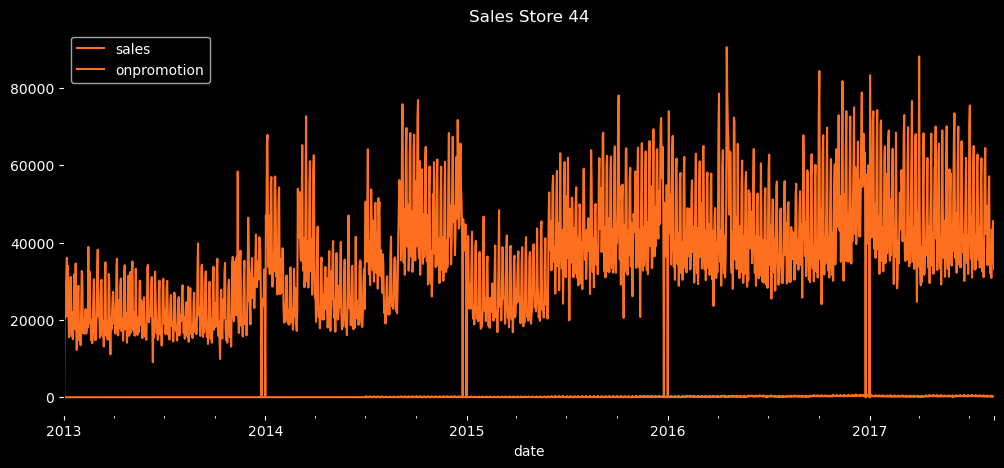

In [416]:
# grafik sales
ts.plot(
    figsize=(12,5),
    color="#FF6F20",
    title='Sales Store 44')
plt.show()

In [417]:
# split
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

In [418]:
train_size

1350

In [419]:
train

,sales,onpromotion
date,,
2013-01-01,0.00,0.00
2013-01-02,30095.18,0.00
2013-01-03,20447.06,0.00
2013-01-04,22795.80,0.00
2013-01-05,31382.51,0.00
...,...,...
2016-09-07,45278.67,353.00
2016-09-08,31337.40,126.00
2016-09-09,38539.64,344.00


In [420]:
test

,sales,onpromotion
date,,
2016-09-12,38192.40,125.00
2016-09-13,30423.02,113.00
2016-09-14,40323.42,334.00
2016-09-15,29761.39,202.00
2016-09-16,43159.86,441.00
...,...,...
2017-08-11,43330.50,389.00
2017-08-12,41559.97,181.00
2017-08-13,45604.44,185.00


In [421]:
# train untuk sales
y_train = train['sales']
y_test = test['sales']

# train untuk onpromotion
exog_train = train[['onpromotion']]
exog_test = test[['onpromotion']]

In [422]:
# cek stationer
result = adfuller(y_train)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print('sudah stationer')
else:
    print('perlu smoothing')

ADF Statistic: -2.919880732592887
p-value: 0.04308450206131244
sudah stationer


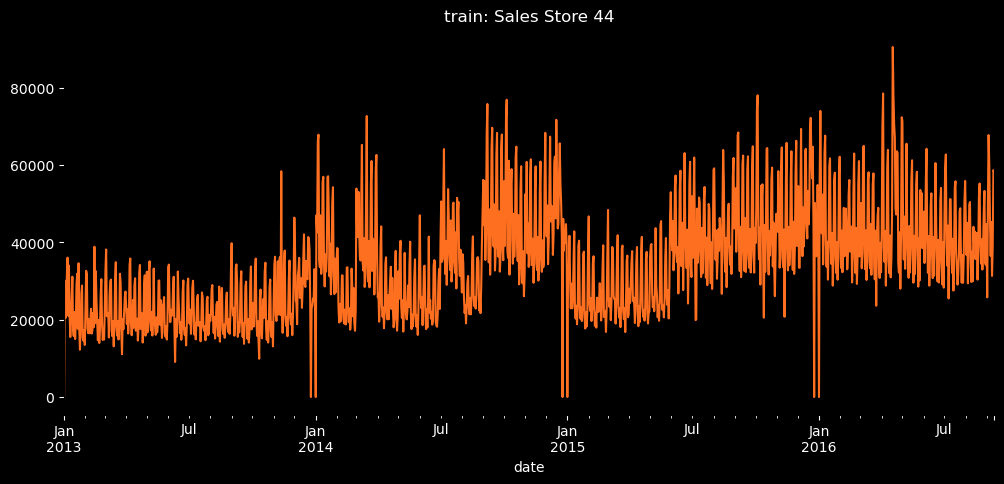

In [423]:
# grafik sales
y_train.plot(
    figsize=(12,5),
    color="#FF6F20",
    title='train: Sales Store 44')
plt.show()

In [424]:
# smoothing dengan differencing
y_train_diff = y_train.diff().dropna()

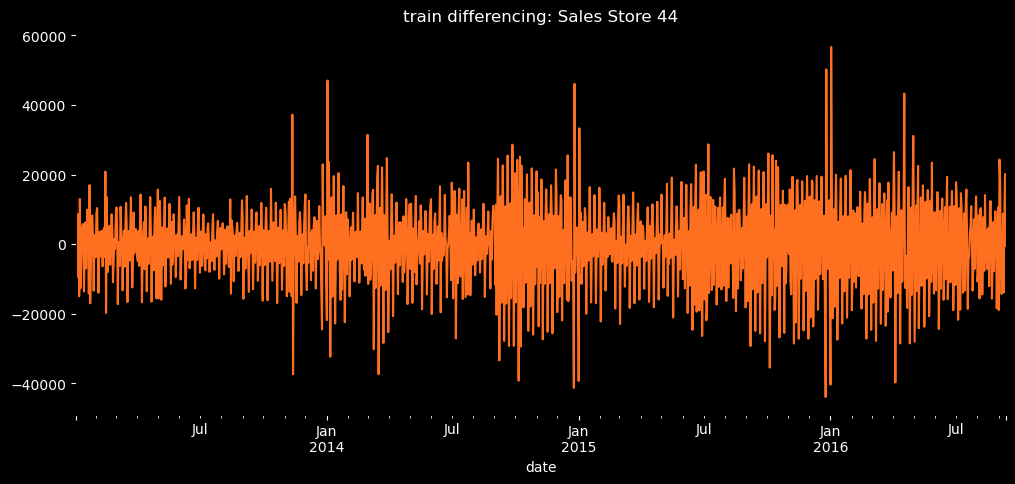

In [425]:
# grafik train setelah differancing
# grafik sales
y_train_diff.plot(
    figsize=(12,5),
    color="#FF6F20",
    title='train differencing: Sales Store 44')
plt.show()

In [426]:
# cek stationer
result = adfuller(y_train_diff)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print('sudah stationer')
else:
    print('perlu smoothing')

ADF Statistic: -9.112784754048999
p-value: 3.3643107914687315e-15
sudah stationer


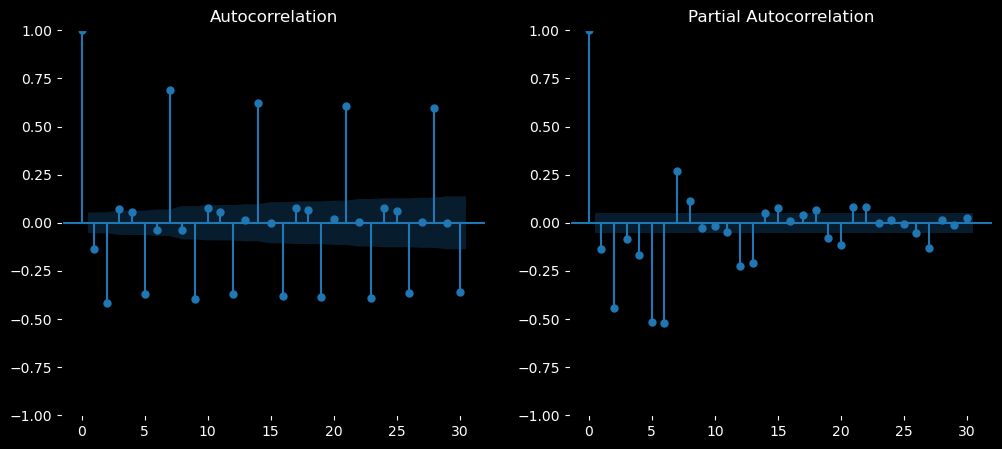

In [427]:
# Pemeriksaan acf dan pacf
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(y_train_diff, lags=30, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(y_train_diff, lags=30, ax=plt.gca())

plt.show()

ACF:
- spike siginifikan pada lag 7, 14, 21: terdapat seasonality
PACF:
- siginifikan pada lag2


In [428]:
# uji model SARIMAX dengan y_test
candidates = [
    (1,0,1),
    (2,0,1),
    (1,0,2),
    (2,0,2)
]

results = []

for order in candidates:
    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False)
        
        forecast = model_fit.forecast(steps=len(y_test))
        
        mae = mean_absolute_error(y_test, forecast)
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        
        results.append({
            'order': order,
            'AIC': model_fit.aic,
            'MAE': mae,
            'RMSE': rmse
        })
        
    except:
        continue

In [429]:
print("Train:", y_train.shape)
print("Test:", y_test.shape)
print("NaN train:", y_train.isna().sum())
print("NaN test:", y_test.isna().sum())

Train: (1350,)
Test: (338,)
NaN train: 0
NaN test: 0


In [430]:
results = pd.DataFrame(results).sort_values(by='RMSE')
print(results)

       order      AIC     MAE     RMSE
2  (1, 0, 2) 27771.44 6303.57  9718.18
3  (2, 0, 2) 27765.55 6303.88  9719.53
1  (2, 0, 1) 27844.15 6324.83  9741.28
0  (1, 0, 1) 28024.39 6646.06 10096.68


In [431]:
results_exog = []

for order in candidates:
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,  # 🔥 ini yang beda
            order=order,
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False)
        
        forecast = model_fit.forecast(
            steps=len(y_test),
            exog=exog_test
        )
        
        mae = mean_absolute_error(y_test, forecast)
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        
        results_exog.append({
            'order': order,
            'AIC': model_fit.aic,
            'MAE': mae,
            'RMSE': rmse
        })
        
    except:
        continue

c:\Users\daryo\anaconda3\envs\data_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\daryo\anaconda3\envs\data_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\daryo\anaconda3\envs\data_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [432]:
results_exog = pd.DataFrame(results_exog).sort_values(by='RMSE')
print(results_exog)

       order      AIC     MAE    RMSE
3  (2, 0, 2) 29071.82 6075.45 8311.65
0  (1, 0, 1) 29153.75 5790.18 8312.29
1  (2, 0, 1) 29108.55 5976.17 8314.99
2  (1, 0, 2) 29064.30 6069.12 8334.45


In [433]:
print(model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                 1350
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 7)   Log Likelihood              -14527.912
Date:                             Thu, 02 Jul 2026   AIC                          29071.824
Time:                                     02:50:28   BIC                          29113.427
Sample:                                 01-01-2013   HQIC                         29087.410
                                      - 09-11-2016                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
onpromotion    53.5726     31.012      1.727      0.084      -7.210     114.355
ar.L1           0.7529  

In [434]:
ts_final = ts.copy()

# log transform (atasi skew & heteroskedasticity)
ts_final['log_sales'] = np.log1p(ts_final['sales'])

# smoothing
ts_final['log_sales'] = ts_final['log_sales'].rolling(3).mean()

# lag promo
ts_final['promo_lag1'] = ts_final['onpromotion'].shift(1)
# ts_final['promo_lag2'] = ts_final['onpromotion'].shift(2)

# handle missing
ts_final = ts_final.fillna(method='bfill')

C:\Users\daryo\AppData\Local\Temp\ipykernel_44296\3710393611.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_final = ts_final.fillna(method='bfill')


In [435]:
train_size = int(len(ts_final) * 0.8)

train = ts_final[:train_size]
test = ts_final[train_size:]

In [436]:
y_train = train['log_sales']
y_test = test['log_sales']

# exog_cols = ['onpromotion', 'promo_lag1', 'promo_lag2']
exog_cols = ['onpromotion', 'promo_lag1']

exog_train = train[exog_cols]
exog_test = test[exog_cols]

In [437]:
model_final = SARIMAX(
    y_train,
    exog=exog_train,
    order=(2,0,2),                 # disederhanakan
    seasonal_order=(0,1,1,7),      # weekly pattern
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_final_fit = model_final.fit()

print(model_final_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                           log_sales   No. Observations:                 1350
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 7)   Log Likelihood                 -24.079
Date:                             Thu, 02 Jul 2026   AIC                             64.158
Time:                                     02:50:32   BIC                            105.719
Sample:                                 01-01-2013   HQIC                            79.732
                                      - 09-11-2016                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
onpromotion     0.0001   5.33e-05      2.153      0.031    1.03e-05       0.000
promo_lag1   6.349e-05  

c:\Users\daryo\anaconda3\envs\data_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [438]:
forecast_log = model_final_fit.forecast(
    steps=len(y_test),
    exog=exog_test
)

In [439]:
forecast = np.expm1(forecast_log)
actual = np.expm1(y_test)

In [440]:
mae = mean_absolute_error(actual, forecast)
rmse = np.sqrt(mean_squared_error(actual, forecast))

print("FINAL MAE:", mae)
print("FINAL RMSE:", rmse)

FINAL MAE: 4825.810308007825
FINAL RMSE: 8523.546177449352


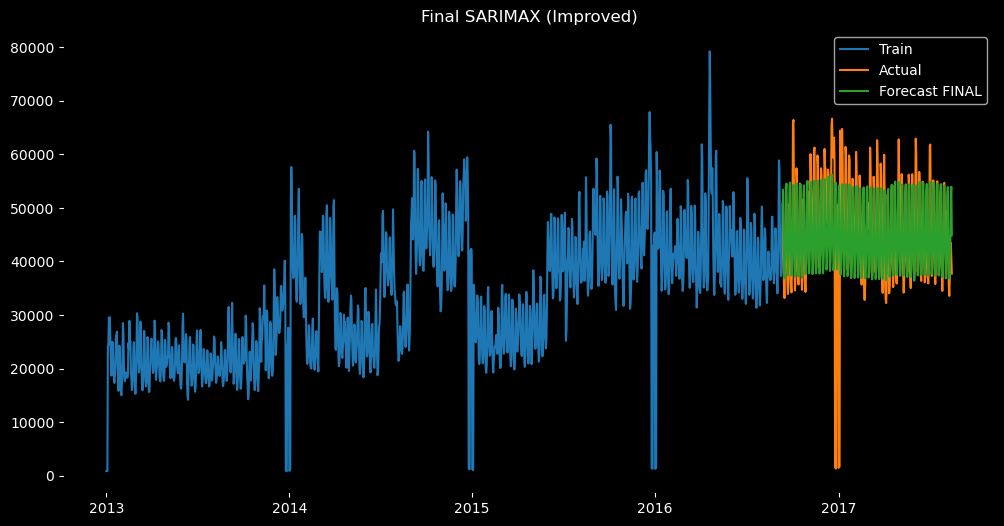

In [441]:
plt.figure(figsize=(12,6))

plt.plot(train.index, np.expm1(y_train), label='Train')
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, forecast, label='Forecast FINAL')

plt.legend()
plt.title("Final SARIMAX (Improved)")
plt.show()

In [442]:
n_days = 30

In [443]:
future_exog = exog_test[exog_cols].iloc[:n_days].copy()

In [444]:
print("Train exog shape:", exog_train.shape)
print("Future exog shape:", future_exog.shape)

Train exog shape: (1350, 2)
Future exog shape: (30, 2)


In [445]:
forecast_obj = model_final_fit.get_forecast(
    steps=n_days,
    exog=future_exog
)

# hasil masih dalam log scale
forecast_log = forecast_obj.predicted_mean

# balik ke skala asli
forecast_30d = np.expm1(forecast_log)
forecast_30d = pd.Series(forecast_30d).rolling(3).mean().fillna(method='bfill')

C:\Users\daryo\AppData\Local\Temp\ipykernel_44296\3701262266.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  forecast_30d = pd.Series(forecast_30d).rolling(3).mean().fillna(method='bfill')


In [446]:
actual_30d = np.expm1(y_test.iloc[:n_days])

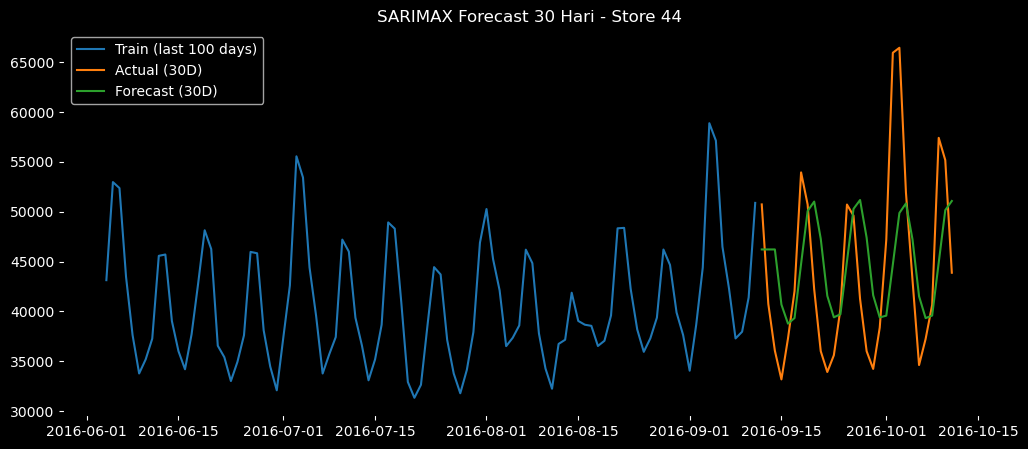

In [447]:
plt.figure(figsize=(12,5))

# Train (opsional: tampilkan sebagian biar tidak terlalu padat)
plt.plot(train.index[-100:], np.expm1(y_train[-100:]), label='Train (last 100 days)')

# Actual
plt.plot(test.index[:n_days], actual_30d, label='Actual (30D)')

# Forecast
plt.plot(test.index[:n_days], forecast_30d, label='Forecast (30D)')

plt.legend()
plt.title('SARIMAX Forecast 30 Hari - Store 44')
plt.show()

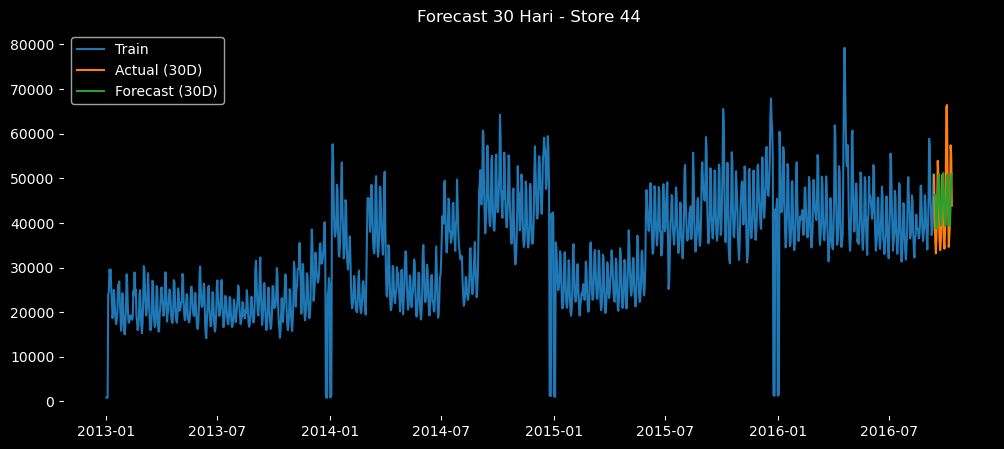

In [448]:
plt.figure(figsize=(12,5))

# Train
plt.plot(train.index, np.expm1(train['log_sales']), label='Train')

# Actual 30 hari
plt.plot(test.index[:n_days], actual_30d, label='Actual (30D)')

# Forecast 30 hari
plt.plot(test.index[:n_days], forecast_30d, label='Forecast (30D)')

plt.legend()
plt.title('Forecast 30 Hari - Store 44')
plt.show()

In [449]:
ts_xgb = ts.copy()

# target transform
ts_xgb['log_sales'] = np.log1p(ts_xgb['sales'])

# exogenous
ts_xgb['promo_lag1'] = ts_xgb['onpromotion'].shift(1)
ts_xgb['promo_lag2'] = ts_xgb['onpromotion'].shift(2)

# 🔥 lag target (WAJIB untuk XGBoost)
ts_xgb['lag1'] = ts_xgb['log_sales'].shift(1)
ts_xgb['lag7'] = ts_xgb['log_sales'].shift(7)

# rolling (biar smooth & stabil)
ts_xgb['rolling_mean_7'] = ts_xgb['log_sales'].rolling(7).mean()

# handle missing
ts_xgb = ts_xgb.fillna(method='bfill')

C:\Users\daryo\AppData\Local\Temp\ipykernel_44296\949409615.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_xgb = ts_xgb.fillna(method='bfill')


In [450]:
train_size = int(len(ts_xgb) * 0.8)

train = ts_xgb.iloc[:train_size]
test  = ts_xgb.iloc[train_size:]

In [451]:
features = [
    'onpromotion',
    'promo_lag1',
    'promo_lag2',
    'lag1',
    'lag7',
    'rolling_mean_7'
]

X_train = train[features]
y_train = train['log_sales']

X_test = test[features]
y_test = test['log_sales']

In [452]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [453]:
n_days = 30

forecast = []
last_data = ts_xgb.copy()

for i in range(n_days):
    
    row = last_data.iloc[-1:].copy()
    
    # update lag features
    row['lag1'] = last_data['log_sales'].iloc[-1]
    row['lag7'] = last_data['log_sales'].iloc[-7]
    row['rolling_mean_7'] = last_data['log_sales'].iloc[-7:].mean()
    
    # ambil promo dari test
    row['onpromotion'] = test['onpromotion'].iloc[i]
    row['promo_lag1'] = test['onpromotion'].iloc[i-1] if i > 0 else 0
    row['promo_lag2'] = test['onpromotion'].iloc[i-2] if i > 1 else 0
    
    X_pred = row[features]
    
    pred_log = model.predict(X_pred)[0]
    
    forecast.append(pred_log)
    
    # append hasil ke dataset (recursive)
    row['log_sales'] = pred_log
    last_data = pd.concat([last_data, row])

In [454]:
forecast_30d = np.expm1(forecast)
actual_30d = np.expm1(y_test.iloc[:n_days])

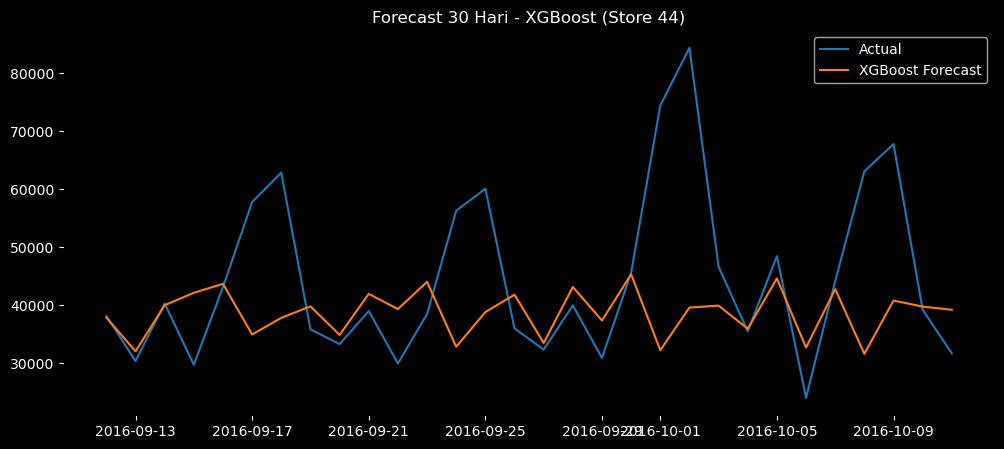

In [455]:
plt.figure(figsize=(12,5))

# actual
plt.plot(test.index[:n_days], actual_30d, label='Actual')

# forecast
plt.plot(test.index[:n_days], forecast_30d, label='XGBoost Forecast')

plt.legend()
plt.title('Forecast 30 Hari - XGBoost (Store 44)')
plt.show()

In [456]:
n_forecast = 16 

In [ ]:
last_14 = ts_final[['onpromotion']].tail(14)

future_onpromo = np.tile(last_14.values, (2,1))[:16]

future_exog = pd.DataFrame(future_onpromo, columns=['onpromotion'])

In [462]:
future_dates = pd.date_range(
    start=ts_final.index[-1] + pd.Timedelta(days=1),
    periods=n_forecast,
    freq='D'
)

future_exog = pd.DataFrame(index=future_dates)

last_14 = ts_final[['onpromotion']].tail(14)
future_onpromo = np.tile(last_14.values, (2,1))[:16]
future_exog = pd.DataFrame(future_onpromo, columns=['onpromotion'])

# generate lag
future_exog['promo_lag1'] = future_exog['onpromotion'].shift(1)

future_exog = future_exog.fillna(method='bfill')

C:\Users\daryo\AppData\Local\Temp\ipykernel_44296\602725098.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_exog = future_exog.fillna(method='bfill')


In [463]:
forecast = model_final_fit.get_forecast(
    steps=n_forecast,
    exog=future_exog
)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [465]:
forecast_final = np.expm1(forecast_mean)

In [466]:
forecast_index = pd.date_range(
    start=ts_final.index[-1] + pd.Timedelta(days=1),
    periods=n_forecast,
    freq='D'
)

forecast_final.index = forecast_index

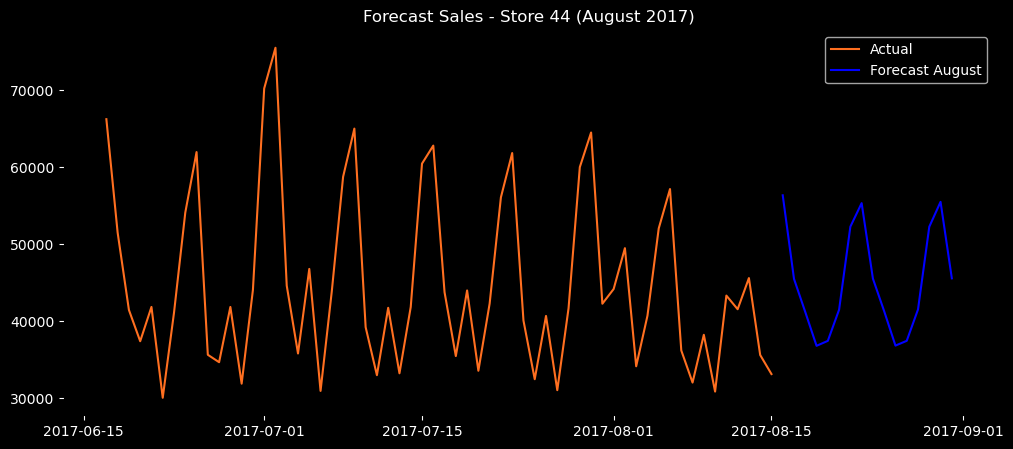

In [468]:
plt.figure(figsize=(12,5))

# data asli
plt.plot(ts['sales'].iloc[-60:], label='Actual', color='#FF6F20')

# forecast
plt.plot(forecast_final, label='Forecast August', color='blue')

plt.title('Forecast Sales - Store 44 (August 2017)')
plt.legend()
plt.show()

In [469]:
forecast_df = pd.DataFrame({
    'date': pd.date_range(
        start=ts_final.index[-1] + pd.Timedelta(days=1),
        periods=n_forecast,
        freq='D'
    ),
    'forecast_sales': forecast_final.values
})

print(forecast_df)

         date  forecast_sales
0  2017-08-16        56351.74
1  2017-08-17        45496.70
2  2017-08-18        41191.46
3  2017-08-19        36808.97
4  2017-08-20        37452.74
5  2017-08-21        41497.44
6  2017-08-22        52278.19
7  2017-08-23        55332.02
8  2017-08-24        45533.31
9  2017-08-25        41294.84
10 2017-08-26        36836.82
11 2017-08-27        37458.72
12 2017-08-28        41529.34
13 2017-08-29        52264.83
14 2017-08-30        55498.75
15 2017-08-31        45570.17
